# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING DATSET

In [2]:
df = pd.read_csv("Zomato_data.csv")
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


# BASIC INFORMATIONS

df.head()

In [5]:
df.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9/5,47,200,Dining


In [7]:
df.shape

(148, 7)

# DATSET INFO

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


# CHECKING NULL/MISSING VALUES

In [13]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

# CHECKING DUPLICATE ROWS

In [14]:
df.duplicated().sum()

np.int64(0)

# DATA CLEANING : Convert rating into numeric

In [8]:
df['rate'].unique()

<ArrowStringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',  '2.9/5',  '3.5/5',  '2.6/5', '3.8 /5',  '3.4/5']
Length: 20, dtype: str

In [58]:
def handle_rating(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

df['rate'] = df['rate'].apply(handle_rating)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


# STATISTICAL SUMMARY

In [17]:
df.describe()

,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000
mean,3.633108,264.810811,418.243243
std,0.402271,653.676951,223.085098
min,2.600000,0.000000,100.000000
25%,3.300000,6.750000,200.000000
50%,3.700000,43.500000,400.000000
75%,3.900000,221.750000,600.000000
max,4.600000,4884.000000,950.000000


# RESTAURANT TYPES ANALYSIS

In [3]:
rest_type = df['listed_in(type)'].value_counts()
rest_type

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

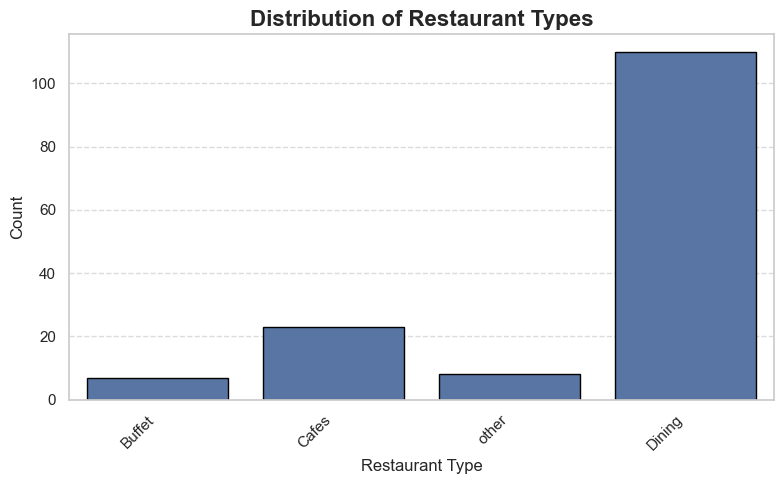

In [5]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))

palette = sns.color_palette("Set2")

sns.countplot(
    data=df, 
    x='listed_in(type)', 
    edgecolor="black",
)

plt.title("Distribution of Restaurant Types", fontsize=16, fontweight='bold')
plt.xlabel("Restaurant Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## CONCLUSION: The majority of restaurants falls into dining category. 
## hence we conclude that, dining restaurants are preffered by a larger no of individuals.

# RESATURANT TYPES VS VOTES ANALYSIS

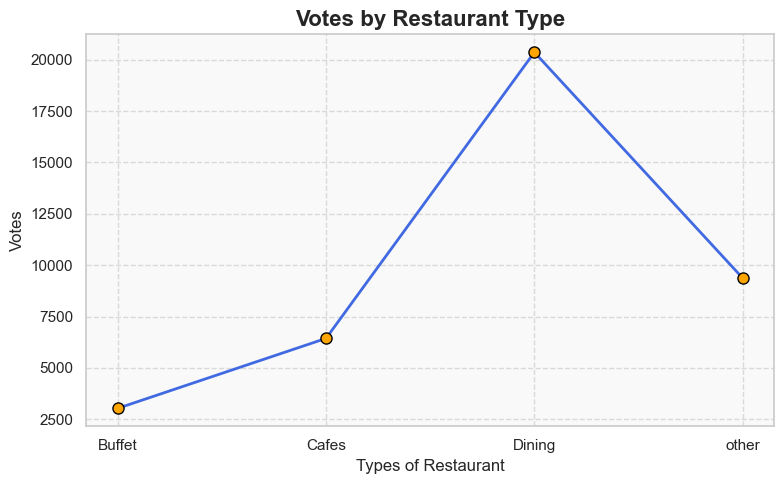

In [34]:
group_data = df.groupby('listed_in(type)')['votes'].sum()
votess = pd.DataFrame({'votes':group_data})

plt.figure(figsize=(8,5))

plt.plot(
    votess, 
    marker='o', 
    linestyle='-', 
    linewidth=2, 
    markersize=8, 
    color='royalblue', 
    markerfacecolor='orange', 
    markeredgecolor='black'
)

plt.title("Votes by Restaurant Type", fontsize=16, fontweight='bold')
plt.xlabel("Types of Restaurant", fontsize=12)
plt.ylabel("Votes", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().set_facecolor("#f9f9f9")
plt.tight_layout()
plt.show()

## CONCLUSION : Majority of the restaurants got votes but dining types dominats in votes.

# RESTAURANT TYPES VS RATING ANALYSIS

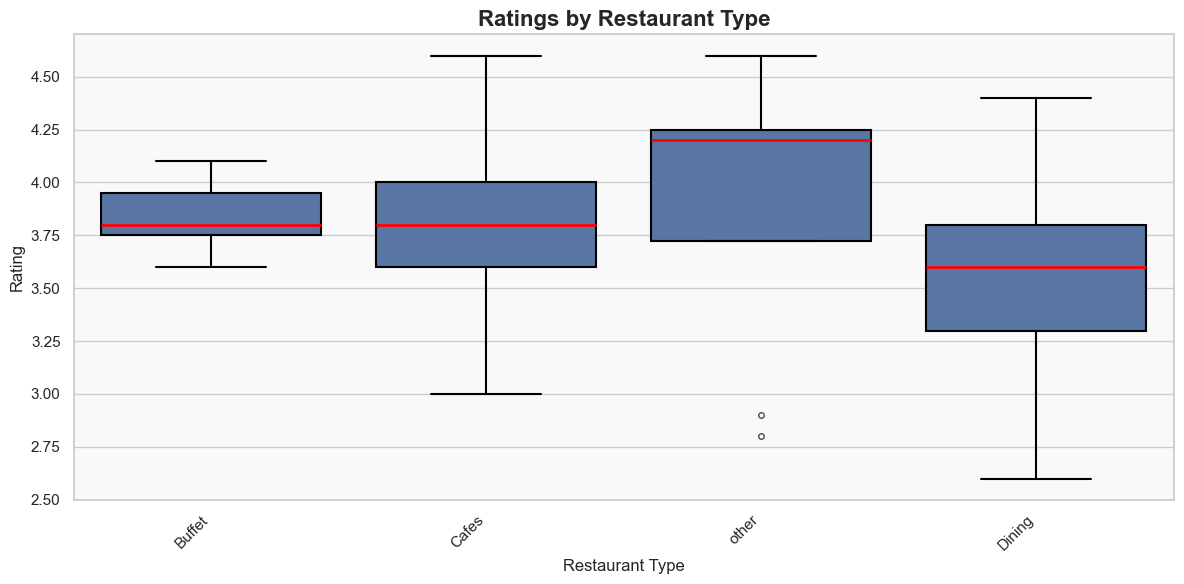

In [41]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,6))

palette = sns.color_palette("pastel")

sns.boxplot(
    data=df, 
    x='listed_in(type)', 
    y='rate', 
    linewidth=1.5,
    fliersize=4,   # size of outlier points
    boxprops={'edgecolor':'black'},
    whiskerprops={'color':'black'},
    capprops={'color':'black'},
    medianprops={'color':'red', 'linewidth':2}
)

plt.title("Ratings by Restaurant Type", fontsize=16, fontweight='bold')
plt.xlabel("Restaurant Type", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().set_facecolor("#f9f9f9")
plt.tight_layout()
plt.show()

## CONCLUSION : majority of reastaurants received ratings between 3.5 to 4.

# COST OF 2 PEOPLE'S FOOD ANALYSIS

In [6]:
cost_2 = df['approx_cost(for two people)'].value_counts()
cost_2

approx_cost(for two people)
300    23
200    16
150    16
400    15
500    14
600    13
800    12
450     6
100     6
250     6
700     5
550     3
750     3
350     3
650     2
900     2
850     2
950     1
Name: count, dtype: int64

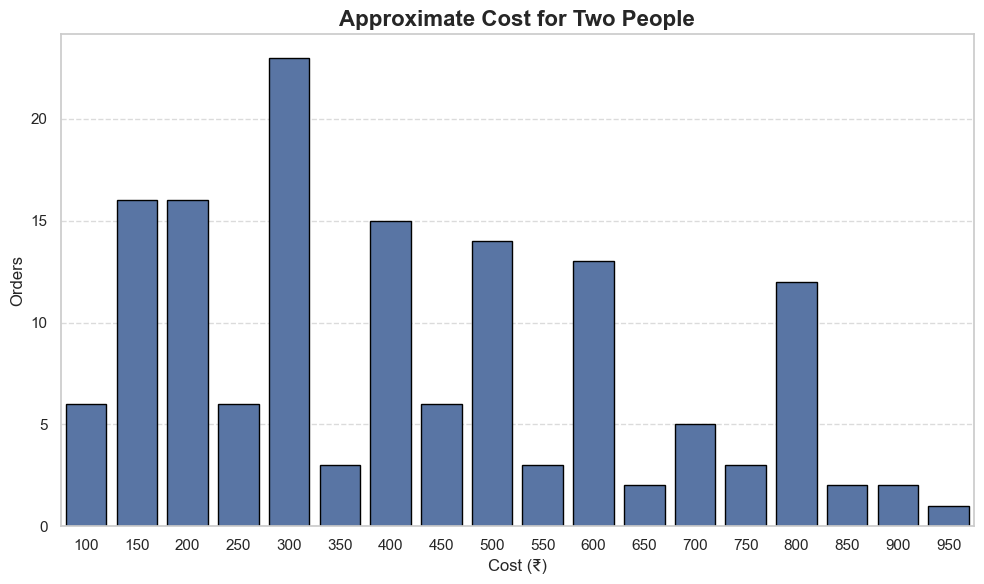

In [16]:
plt.figure(figsize=(10,6))

palette = sns.color_palette("pastel")

sns.barplot(
    x=cost_2.index, 
    y=cost_2.values, 
    edgecolor="black"
)

plt.title("Approximate Cost for Two People", fontsize=16, fontweight='bold')
plt.xlabel("Cost (₹)", fontsize=12)
plt.ylabel("Orders", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## CONCLUSION : the majority of couples preffers restaurant with an approximate cost of 300₹.

# ONLINE ORDER DISTRIBUTION ANALYSIS

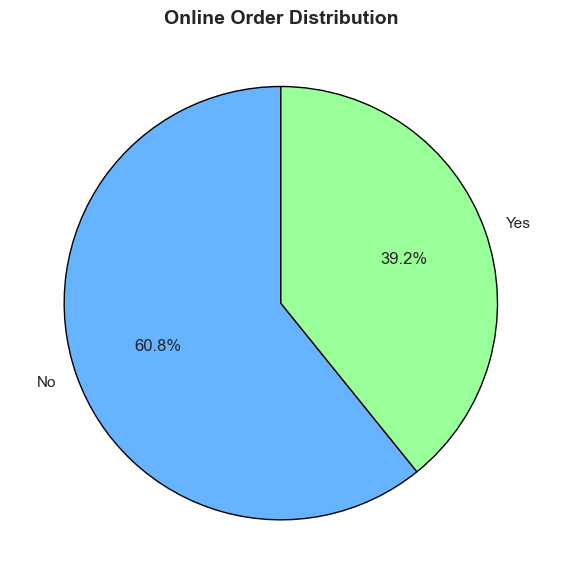

In [20]:
online_dist = df['online_order'].value_counts()

plt.figure(figsize=(6,6))
colors = ['#66b3ff','#99ff99','#ff9999','#ffcc99']  # custom colors

plt.pie(
    online_dist,
    labels=online_dist.index,
    autopct='%1.1f%%',   # show percentages
    startangle=90,       # rotate chart for better look
    colors=colors,
    wedgeprops={'edgecolor':'black'}  # black edges for clarity
)

plt.title("Online Order Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## CONCLUSION : majority people prefer offline orders compared to online orders.

# ONLINE VS OFFLINE RATING ANALYSIS

C:\Users\hp\AppData\Local\Temp\ipykernel_6568\4234811833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


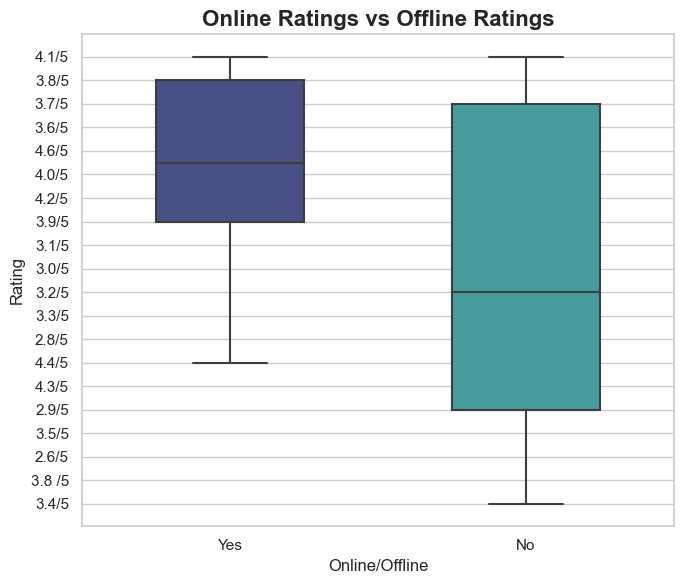

In [29]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,6))

sns.boxplot(
    data=df, 
    x='online_order', 
    y='rate',
    palette='mako',
    width=0.5,
    fliersize=4,   # size of outlier points
    linewidth=1.5  # thicker box edges
)

plt.title("Online Ratings vs Offline Ratings", fontsize=16, fontweight='bold')
plt.xlabel("Online/Offline", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.tight_layout()
plt.show()

## CONCLUSION : offline orders received less ratings compared to rating received on online orders.

# RESTAURANT TYPES VS ORDERS TYPES ANALYSIS

In [31]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [39]:
pivot_tab = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
pivot_tab

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


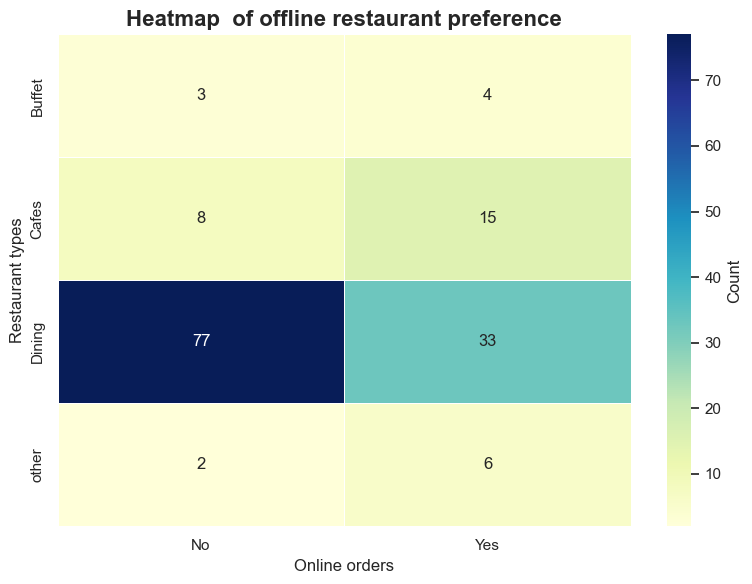

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_tab, 
    annot=True,        # show values inside cells
    fmt="d",           # integer format
    cmap="YlGnBu",     # color palette
    linewidths=0.5,    # thin lines between cells
    cbar_kws={'label': 'Count'}  # colorbar label
)

plt.title("Heatmap  of offline restaurant preference", fontsize=16, fontweight='bold')
plt.xlabel("Online orders", fontsize=12)
plt.ylabel("Restaurant types", fontsize=12)
plt.tight_layout()
plt.show()

## CONCLUSION : in buffet people prefer both online offline equally.
##              in cafes people prefer online orders mostly.
##              in dining people prefer offline orders mostly.

# ORDERS VS VOTES ANALYSIS

C:\Users\hp\AppData\Local\Temp\ipykernel_6568\169208205.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hp\AppData\Local\Temp\ipykernel_6568\169208205.py:7: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(


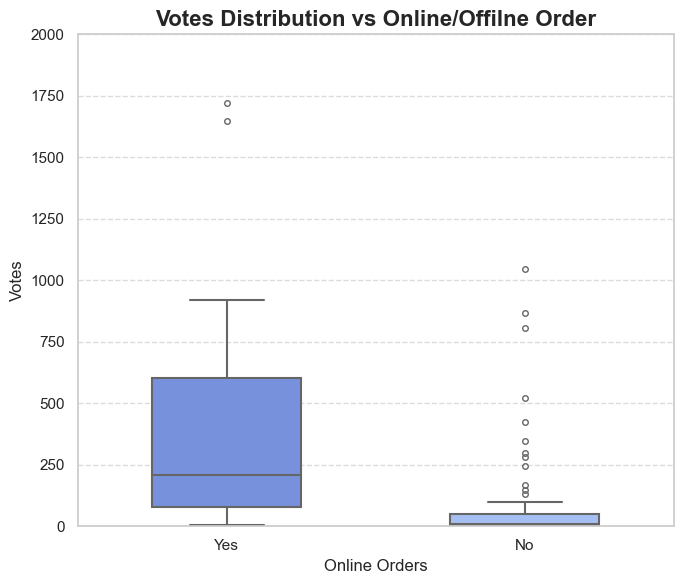

In [73]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7,6))

palette = sns.color_palette("coolwarm")

sns.boxplot(
    data=df, 
    x='online_order', 
    y='votes', 
    palette=palette,
    width=0.5,
    fliersize=4,   # size of outlier points
    linewidth=1.5  # thicker box edges
)

plt.ylim(0,2000)
plt.title("Votes Distribution vs Online/Offilne Order", fontsize=16, fontweight='bold')
plt.xlabel("Online Orders", fontsize=12)
plt.ylabel("Votes", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## CONCLUSION : online orders have received higher vote counts compared to offline orders.

# TOP RESTAURANT ANALYSIS

### ACCORDING TO RATINGS

In [71]:
df.sort_values('rate', ascending=False).head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),cost_category
7,Onesta,Yes,Yes,4.6,2556,600,Cafes,Medium


### ACCORDING TO VOTES

In [72]:
df.sort_values('votes', ascending=False).head(1)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),cost_category
38,Empire Restaurant,Yes,No,4.4,4884,750,other,High


## CONCLUSION : top restaurant according to ratings is 'Onesta' & according to votes is 'Empire REstaurant'.

# CORRELATION ANALYSIS OF ZOMATO DATSET

In [59]:
num = df.select_dtypes(include=np.number)
num.corr()

,rate,votes,approx_cost(for two people)
rate,1.000000,0.489844,0.275216
votes,0.489844,1.000000,0.324372
approx_cost(for two people),0.275216,0.324372,1.000000


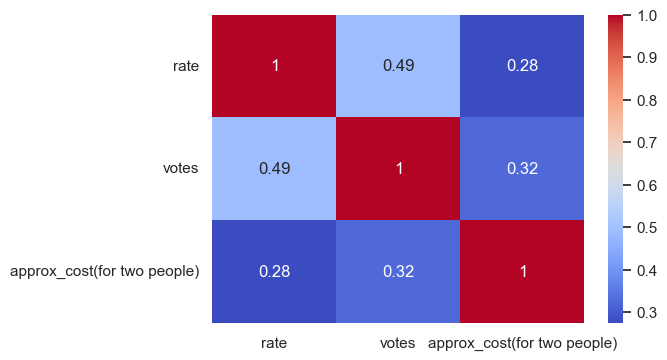

In [60]:
plt.figure(figsize=(6,4))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.show()

## CONCLUSION : we get to know about correlations of : 1) Rating vs Votes correlation
##                                                     2) Cost vs Rating correlation

# OUTLIERS DETECTION

In [74]:
Q1 = df['votes'].quantile(0.25)
Q3 = df['votes'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[(df['votes'] < lower) | (df['votes'] > upper)]
outliers

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),cost_category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,High
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,High
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,High
7,Onesta,Yes,Yes,4.6,2556,600,Cafes,Medium
14,San Churro Cafe,Yes,No,3.8,918,800,Cafes,High
37,Szechuan Dragon,Yes,No,4.2,1647,600,Dining,Medium
38,Empire Restaurant,Yes,No,4.4,4884,750,other,High
44,Onesta,Yes,Yes,4.6,2556,600,other,Medium
47,Recipe,Yes,No,4.0,804,450,Dining,Medium
48,Beijing Bites,Yes,No,3.7,679,850,Dining,High


# FEATURE ENGINEERING : CREATING NEW cost_category COLUMN

In [66]:
df['cost_category'] = pd.cut(
    df['approx_cost(for two people)'],
    bins=[0,300,600,1000,5000],
    labels=['Low','Medium','High','Luxury']
)

df['cost_category'].value_counts()

cost_category
Low       67
Medium    54
High      27
Luxury     0
Name: count, dtype: int64

In [67]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),cost_category
0,Jalsa,Yes,Yes,4.1,775,800,Buffet,High
1,Spice Elephant,Yes,No,4.1,787,800,Buffet,High
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet,High
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet,Low
4,Grand Village,No,No,3.8,166,600,Buffet,Medium


# CHECKING SKEWNESS

In [68]:
df['votes'].skew()

np.float64(4.936309828623457)

## CONCLUSION : skewness of 4.93 indicates a highly right-skewed (positively skewed) distribution.
## ✅ Very large positive skew
## ✅ Most values are concentrated on the left / lower side
## ✅ A few very large outliers pull the distribution to the right

# CHECKING KURTOSIS

In [69]:
df['votes'].kurt()

np.float64(28.486743630617504)

## CONCLUSION : A kurtosis of 28.48 is extremely high.
## ✅ Very sharp peak
## ✅ Extremely heavy tails
## ✅ Many extreme values / outliers present

# KEY INSIGHTS :- 
#   MOST RESTAURANTS BELONG TO DINING CATEGORY
#  ONLINE ORDER IS AVAILABLE FOR MANY RESTAURANTS
#   HIGHER VOTES OFTEN CORRELATE WITH BETTER RATINGS
#   SOME RESTAURANTS ARE EXTREME OUTLIERS IN VOTES
#   MID-RANGE COST RESTAURANTS DOMINATE THE DATASET
#   TABLE BOOKING RESTAURANTS GENERALLY HAVE BETTER RATINGS

# ............... THANK YOU ...............